# Lab 4 - SmartStay Advisors

SmartStay Advisors es una firma intermediaria especializada en la búsqueda y selección de propiedades en Airbnb para clientes corporativos y particulares. A partir de los requerimientos de los clientes y del análisis de la oferta disponible, la empresa busca optimizar variables clave como precio, calidad y disponibilidad, además de aprovechar oportunidades de negocio en propiedades con bajo nivel de ocupación.  

En este contexto, el proyecto tiene como objetivo aplicar modelos predictivos y de clasificación que permitan estimar el valor por noche de las viviendas, identificar patrones relevantes en la ocupación y generar estrategias basadas en datos para mejorar la rentabilidad. Como parte de la consultoría, también se construirá una variable categórica del precio de las propiedades, clasificándolas en económicas, intermedias o caras, para apoyar el análisis comparativo entre distintos algoritmos de minería de datos. 



## Ejercicio 1 - Carga del conjunto de datos

Se utiliza el archivo `listings.RData` provisto en el repositorio.
La libreria `pyreadr` permite importar el objeto de R de forma reproducible.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

In [2]:
rdata = pyreadr.read_r('listings.RData')
tabla_principal = list(rdata.keys())[0]
df_raw = rdata[tabla_principal].copy()

print(f'Tabla cargada: {tabla_principal}')
print(f'Dimensiones iniciales: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')

Tabla cargada: listings
Dimensiones iniciales: 171748 filas x 80 columnas


## Ejercicio 2 - Analisis exploratorio extenso

### 2.1 Preprocesamiento inicial
La variable `price` viene como texto con simbolo de moneda y separadores.
Para poder modelar, se convierte a numerica (`price_num`) y se eliminan valores vacios.
Ademas, para el EDA se acota el rango a precios plausibles entre 10 y 5000 por noche, con el fin de reducir el impacto de outliers extremos en la interpretacion descriptiva.

In [3]:
df = df_raw.copy()

price_limpio = (
    df['price'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)

df['price_num'] = pd.to_numeric(price_limpio, errors='coerce')

print('Filas totales:', len(df))
print('Filas con precio valido:', int(df['price_num'].notna().sum()))
print('Porcentaje con precio valido:', round(df['price_num'].notna().mean() * 100, 2), '%')

Filas totales: 171748
Filas con precio valido: 76246
Porcentaje con precio valido: 44.39 %


In [4]:
df_eda = df[df['price_num'].between(10, 5000)].copy()

print('Filas para EDA (precio entre 10 y 5000):', len(df_eda))
print('Cuantiles de price_num:')
print(df_eda['price_num'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]).round(2))

Filas para EDA (precio entre 10 y 5000): 75126
Cuantiles de price_num:
0.00      10.0
0.25     119.0
0.50     190.0
0.75     317.0
0.90     574.0
0.95     875.0
0.99    2014.0
1.00    5000.0
Name: price_num, dtype: float64


In [5]:
faltantes = (df_eda.isna().mean().sort_values(ascending=False) * 100).round(2)
print('Top 15 variables con mayor porcentaje de faltantes:')
print(faltantes.head(15))

numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df_eda.select_dtypes(exclude=[np.number]).columns.tolist()

print('Cantidad de variables numericas:', len(numericas))
print('Cantidad de variables categoricas:', len(categoricas))

Top 15 variables con mayor porcentaje de faltantes:
calendar_updated                100.00
neighbourhood_group_cleansed     50.31
review_scores_checkin            16.79
review_scores_communication      16.79
review_scores_value              16.79
review_scores_cleanliness        16.79
review_scores_accuracy           16.79
review_scores_location           16.79
review_scores_rating             16.79
reviews_per_month                16.79
license                          13.92
host_total_listings_count         0.83
host_listings_count               0.83
bedrooms                          0.16
beds                              0.11
dtype: float64
Cantidad de variables numericas: 34
Cantidad de variables categoricas: 47


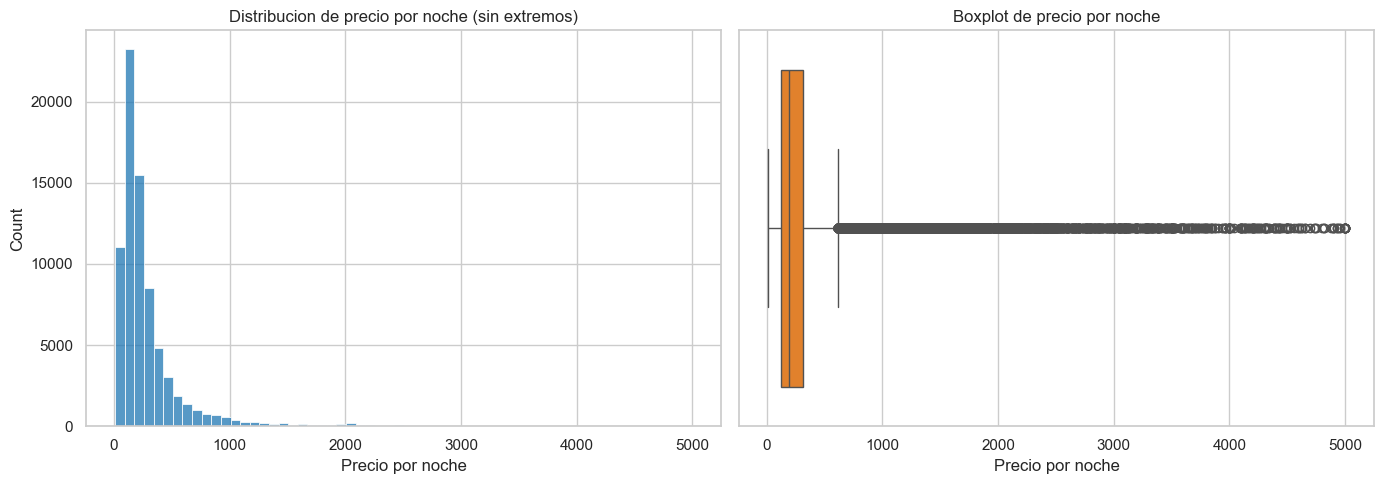

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_eda['price_num'], bins=60, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de precio por noche (sin extremos)')
axes[0].set_xlabel('Precio por noche')

sns.boxplot(x=df_eda['price_num'], ax=axes[1], color='#ff7f0e')
axes[1].set_title('Boxplot de precio por noche')
axes[1].set_xlabel('Precio por noche')

plt.tight_layout()
plt.show()

In [7]:
for col in ['room_type', 'property_type', 'host_is_superhost']:
    if col in df_eda.columns:
        print(f'\nFrecuencias principales de {col}:')
        print(df_eda[col].value_counts(dropna=False).head(10))
        print(f'\nMediana de precio por {col}:')
        print(df_eda.groupby(col)['price_num'].median().sort_values(ascending=False).head(10).round(2))


Frecuencias principales de room_type:
room_type
Entire home/apt    65141
Private room        9483
Hotel room           290
Shared room          212
Name: count, dtype: int64

Mediana de precio por room_type:
room_type
Hotel room         278.0
Entire home/apt    203.0
Private room        84.0
Shared room         41.0
Name: price_num, dtype: float64

Frecuencias principales de property_type:
property_type
Entire rental unit             20320
Entire condo                   19355
Entire home                    16216
Private room in home            3653
Private room in rental unit     2055
Entire guesthouse               1681
Entire townhouse                1614
Entire guest suite              1595
Room in hotel                   1444
Entire serviced apartment        813
Name: count, dtype: int64

Mediana de precio por property_type:
property_type
Entire home/apt           1181.0
Room in resort             655.0
Entire villa               601.5
Lighthouse                 552.0
Private room

In [8]:
corr_target = (
    df_eda[numericas]
    .corr(numeric_only=True)['price_num']
    .drop('price_num')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(12)
)

print('Variables numericas mas relacionadas con price_num (correlacion lineal):')
print(corr_target.round(3))

Variables numericas mas relacionadas con price_num (correlacion lineal):
bathrooms                                      0.531
accommodates                                   0.471
calculated_host_listings_count_entire_homes    0.223
calculated_host_listings_count                 0.221
estimated_occupancy_l365d                     -0.205
reviews_per_month                             -0.172
longitude                                     -0.157
number_of_reviews_ltm                         -0.154
latitude                                      -0.143
number_of_reviews                             -0.140
number_of_reviews_ly                          -0.138
number_of_reviews_l30d                        -0.127
Name: price_num, dtype: float64


### 2.2 Hallazgos principales del EDA
1. El dataset original tiene 171,748 filas y 80 columnas, pero no todas tienen precio util para modelar.
2. Luego de limpiar `price`, se conservan 76,246 registros con precio numerico y 75,126 para EDA en rango plausible.
3. La distribucion de precio esta sesgada a la derecha; la mediana esta muy por debajo de la cola alta, por lo que conviene robustecer modelos frente a outliers.
4. `room_type` y `property_type` muestran diferencias claras de precio: habitaciones compartidas y privadas tienden a rangos bajos, mientras alojamientos completos tienden a rangos mayores.
5. Variables de capacidad (por ejemplo `accommodates` y `bathrooms`) presentan asociacion positiva con precio, lo que es consistente con la logica de negocio.
6. Hay faltantes relevantes en variables de reviews y algunas columnas administrativas, por lo que se requiere imputacion o exclusion selectiva en la etapa de modelado.

## Ejercicio 3 - Analisis de grupos
Se aplica K-Means con 3 grupos sobre variables numericas representativas del negocio (precio, capacidad, noches minimas, disponibilidad y actividad de reseñas).
Antes de clusterizar se eliminan faltantes en las variables seleccionadas, se recortan extremos (1% y 99%) en variables sensibles y se estandariza la escala.

In [9]:
cluster_features = [
    col for col in [
        'price_num', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
        'minimum_nights', 'availability_365', 'number_of_reviews',
        'reviews_per_month', 'review_scores_rating'
    ] if col in df_eda.columns
]

df_cluster = df_eda[cluster_features].dropna().copy()

for col in ['price_num', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']:
    if col in df_cluster.columns:
        p01, p99 = df_cluster[col].quantile([0.01, 0.99])
        df_cluster[col] = df_cluster[col].clip(lower=p01, upper=p99)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_cluster['cluster'] = kmeans.fit_predict(X_cluster)

print('Tamano de cada grupo:')
print(df_cluster['cluster'].value_counts().sort_index())

print('\nMedianas por grupo:')
print(df_cluster.groupby('cluster')[cluster_features].median().round(2))

Tamano de cada grupo:
cluster
0    36252
1    12229
2    13924
Name: count, dtype: int64

Medianas por grupo:
         price_num  accommodates bedrooms beds  bathrooms  minimum_nights  \
cluster                                                                     
0            167.0           4.0      1.0  2.0        1.0             2.0   
1            446.0           8.0      3.0  5.0        2.5             2.0   
2            139.0           4.0      1.0  2.0        1.0             2.0   

         availability_365  number_of_reviews  reviews_per_month  \
cluster                                                           
0                   258.0               15.0               0.60   
1                   259.0               22.0               0.91   
2                   236.0              155.0               3.39   

         review_scores_rating  
cluster                        
0                        4.88  
1                        4.93  
2                        4.89  


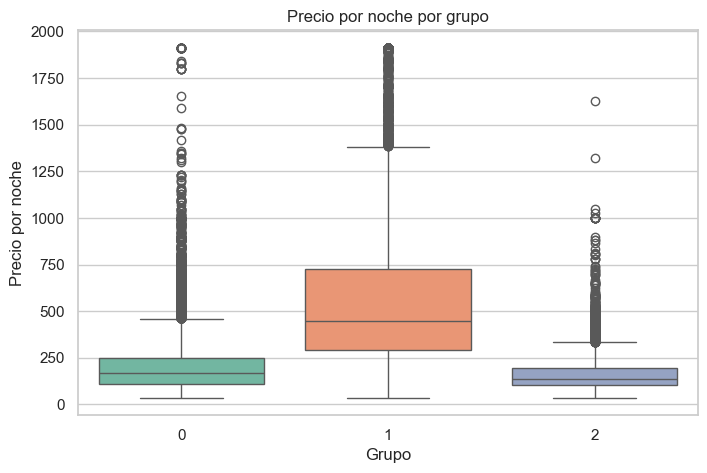

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster, x='cluster', y='price_num', hue='cluster', palette='Set2', legend=False)
plt.title('Precio por noche por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio por noche')
plt.show()

### Caracterizacion de grupos
1. Grupo de alto valor: mayor mediana de precio, mayor capacidad y mas banos/habitaciones; representa propiedades premium.
2. Grupo de alta rotacion: precio medio-bajo pero con muchas reseñas y mayor actividad mensual; sugiere propiedades con alta demanda y buen ajuste precio-mercado.
3. Grupo estandar: precio intermedio y menor intensidad de reseñas que el grupo de alta rotacion; puede requerir estrategias de diferenciacion para elevar ocupacion.

Este analisis de grupos es util para segmentar estrategias comerciales y para crear variables derivadas en modelos posteriores.

## Ejercicio 4 - Division en entrenamiento y prueba
Se construye una variable de categoria de precio en tres niveles (Economica, Intermedia, Cara) con cortes por terciles de `price_num`.
Para mantener la representatividad de esas categorias, la division se hace con estratificacion sobre la nueva variable.

In [11]:
df_model = df_eda.copy()

q1, q2 = df_model['price_num'].quantile([1/3, 2/3])

df_model['categoria_precio'] = pd.cut(
    df_model['price_num'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
)

print(f'Cortes de categoria: <= {q1:.2f}, <= {q2:.2f}, > {q2:.2f}')
print('\nDistribucion general de categorias (%):')
print((df_model['categoria_precio'].value_counts(normalize=True) * 100).round(2))

Cortes de categoria: <= 141.00, <= 262.00, > 262.00

Distribucion general de categorias (%):
categoria_precio
Economica     33.52
Intermedia    33.27
Cara          33.21
Name: proportion, dtype: float64


In [12]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    stratify=df_model['categoria_precio']
)

print('Tamanos de los conjuntos:')
print('Train:', train_df.shape)
print('Test :', test_df.shape)

print('\nDistribucion categoria_precio en Train (%):')
print((train_df['categoria_precio'].value_counts(normalize=True) * 100).round(2))

print('\nDistribucion categoria_precio en Test (%):')
print((test_df['categoria_precio'].value_counts(normalize=True) * 100).round(2))

Tamanos de los conjuntos:
Train: (52588, 82)
Test : (22538, 82)

Distribucion categoria_precio en Train (%):
categoria_precio
Economica     33.52
Intermedia    33.27
Cara          33.21
Name: proportion, dtype: float64

Distribucion categoria_precio en Test (%):
categoria_precio
Economica     33.52
Intermedia    33.27
Cara          33.21
Name: proportion, dtype: float64


### Criterio de division y conclusion
1. Se usa 70% entrenamiento y 30% prueba para mantener suficiente volumen de aprendizaje y evaluacion robusta.
2. La division es estratificada por categoria de precio, por lo que el balance de clases se conserva en ambos conjuntos.
3. En esta etapa no se aplica sobremuestreo ni submuestreo porque las tres categorias quedan practicamente balanceadas por construccion.
4. Este diseno evita sesgos de representacion y deja preparada la base para los siguientes modelos de regresion y clasificacion.

## Ejercicio 5 - Arbol de regresion para predecir precio por noche

En este paso se entrena un arbol de regresion usando todas las variables predictoras disponibles.
Para evitar fuga de informacion, se excluyen columnas que contienen directa o indirectamente el objetivo:
- `price_num` (objetivo numerico)
- `price` (version texto del mismo objetivo)
- `categoria_precio` (derivada del objetivo)

Se usa un pipeline con imputacion para faltantes y OneHotEncoder para variables categoricas.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_col = 'price_num'
cols_excluir = ['price_num', 'price', 'categoria_precio']
cols_excluir = [c for c in cols_excluir if c in train_df.columns]

X_train_reg = train_df.drop(columns=cols_excluir).copy()
X_test_reg = test_df.drop(columns=cols_excluir).copy()
y_train_reg = train_df[target_col].copy()
y_test_reg = test_df[target_col].copy()

# Columnas totalmente vacias no aportan informacion y generan advertencias en imputacion.
cols_all_missing = [c for c in X_train_reg.columns if X_train_reg[c].isna().all()]
if cols_all_missing:
    X_train_reg = X_train_reg.drop(columns=cols_all_missing)
    X_test_reg = X_test_reg.drop(columns=cols_all_missing)

num_cols_reg = X_train_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_reg = X_train_reg.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess_reg = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols_reg),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_reg)
    ]
)

tree_reg = DecisionTreeRegressor(
    random_state=42
    # Sin limite de profundidad en este paso inicial; se tunea en pasos posteriores.
)

modelo_arbol_reg = Pipeline(steps=[
    ('preprocess', preprocess_reg),
    ('model', tree_reg)
])

print('Columnas totalmente vacias excluidas:', cols_all_missing)
print('Variables predictoras numericas:', len(num_cols_reg))
print('Variables predictoras categoricas:', len(cat_cols_reg))
print('Total de filas train:', X_train_reg.shape[0], '| test:', X_test_reg.shape[0])

Columnas totalmente vacias excluidas: ['calendar_updated']
Variables predictoras numericas: 33
Variables predictoras categoricas: 45
Total de filas train: 52588 | test: 22538


In [14]:
modelo_arbol_reg.fit(X_train_reg, y_train_reg)
pred_train = modelo_arbol_reg.predict(X_train_reg)
pred_test = modelo_arbol_reg.predict(X_test_reg)

mae_train = mean_absolute_error(y_train_reg, pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, pred_train))
r2_train = r2_score(y_train_reg, pred_train)

mae_test = mean_absolute_error(y_test_reg, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, pred_test))
r2_test = r2_score(y_test_reg, pred_test)


print('=== Desempeno del arbol de regresion ===')
print(f'Train -> MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R2: {r2_train:.4f}')
print(f'Test  -> MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R2: {r2_test:.4f}')

reg = modelo_arbol_reg.named_steps['model']
print('\nProfundidad del arbol:', reg.get_depth())
print('Numero de hojas:', reg.get_n_leaves())

c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


=== Desempeno del arbol de regresion ===
Train -> MAE: 0.00 | RMSE: 0.00 | R2: 1.0000
Test  -> MAE: 107.72 | RMSE: 259.28 | R2: 0.5302

Profundidad del arbol: 94
Numero de hojas: 47385


### Lectura inicial de resultados

- El modelo usa todas las variables predictoras disponibles despues de imputar faltantes y codificar categorias.
- Si el R2 en entrenamiento es mucho mayor que en prueba, hay evidencia de sobreajuste (comun en arboles sin limite de profundidad).
- En el siguiente paso se recomienda tunear `max_depth`, `min_samples_leaf` y `min_samples_split` con validacion cruzada para mejorar generalizacion.

## Ejercicio 6 - Usar el árbol para predecir y analizar que tan bien lo hizo



c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,Modelo,MAE,RMSE,R2
0,Arbol train,0.0000,0.0000,1.0000
1,Arbol test,107.7195,259.2846,0.5302
2,Baseline test,204.2178,378.3098,-0.0000


Brecha de R2 train-test: 0.4698
Mejora RMSE vs baseline: 31.46%


,real,predicho,error_abs,residuo
15765,5000.0,113.0,4887.0,4887.0
11950,5000.0,600.0,4400.0,4400.0
3209,4800.0,510.0,4290.0,4290.0
3255,355.0,4499.0,4144.0,-4144.0
9530,378.0,4499.0,4121.0,-4121.0
19232,4749.0,1013.0,3736.0,3736.0
1320,3903.0,238.0,3665.0,3665.0
5319,207.0,3643.0,3436.0,-3436.0
20536,3510.0,88.0,3422.0,3422.0
20776,3673.0,334.0,3339.0,3339.0


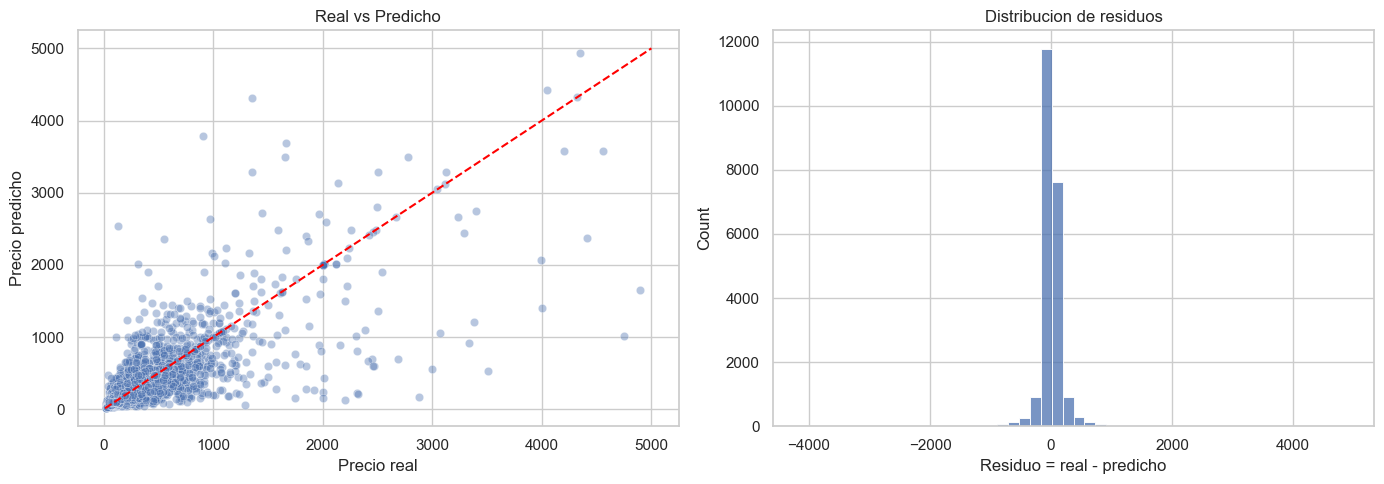

In [15]:

# Predicciones del modelo del ejercicio 5
pred_train = modelo_arbol_reg.predict(X_train_reg)
pred_test = modelo_arbol_reg.predict(X_test_reg)

# Metricas train
mae_train = mean_absolute_error(y_train_reg, pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, pred_train))
r2_train = r2_score(y_train_reg, pred_train)

# Metricas test
mae_test = mean_absolute_error(y_test_reg, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, pred_test))
r2_test = r2_score(y_test_reg, pred_test)

# Baseline: predecir siempre el promedio del train
baseline_pred = np.repeat(y_train_reg.mean(), len(y_test_reg))
baseline_mae = mean_absolute_error(y_test_reg, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_reg, baseline_pred))
baseline_r2 = r2_score(y_test_reg, baseline_pred)

# Resumen
resumen_ej6 = pd.DataFrame({
    'Modelo': ['Arbol train', 'Arbol test', 'Baseline test'],
    'MAE': [mae_train, mae_test, baseline_mae],
    'RMSE': [rmse_train, rmse_test, baseline_rmse],
    'R2': [r2_train, r2_test, baseline_r2]
})

display(resumen_ej6.round(4))

print(f"Brecha de R2 train-test: {r2_train - r2_test:.4f}")
print(f"Mejora RMSE vs baseline: {((baseline_rmse - rmse_test) / baseline_rmse) * 100:.2f}%")

# Tabla real vs predicho
pred_vs_real = pd.DataFrame({
    'real': y_test_reg.values,
    'predicho': pred_test
})
pred_vs_real['error_abs'] = (pred_vs_real['real'] - pred_vs_real['predicho']).abs()
pred_vs_real['residuo'] = pred_vs_real['real'] - pred_vs_real['predicho']

display(pred_vs_real.sort_values('error_abs', ascending=False).head(10))

# Graficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=pred_vs_real.sample(min(5000, len(pred_vs_real)), random_state=42),
                x='real', y='predicho', alpha=0.4, ax=axes[0])
axes[0].plot([pred_vs_real['real'].min(), pred_vs_real['real'].max()],
             [pred_vs_real['real'].min(), pred_vs_real['real'].max()],
             color='red', linestyle='--')
axes[0].set_title('Real vs Predicho')
axes[0].set_xlabel('Precio real')
axes[0].set_ylabel('Precio predicho')

sns.histplot(pred_vs_real['residuo'], bins=50, ax=axes[1])
axes[1].set_title('Distribucion de residuos')
axes[1].set_xlabel('Residuo = real - predicho')

plt.tight_layout()
plt.show()

El árbol de regresión del ejercicio anterior obtuvo un ajuste perfecto en entrenamiento
(MAE = 0.00, RMSE = 0.00 y R² = 1.0000), lo cual indica que el modelo memorizó los datos de train. Este comportamiento es consistente con un árbol sin restricción de profundidad, especialmente al usar todas las variables disponibles. La profundidad alcanzada fue de 94 niveles y el número de hojas fue de 47,385, lo que confirma una estructura extremadamente compleja.

En el conjunto de prueba, el desempeño disminuye a MAE = 107.72, RMSE = 259.28 y R² = 0.5302. La diferencia entre entrenamiento y prueba evidencia *sobreajuste*, ya que el modelo aprende demasiado bien los casos vistos pero generaliza peor en datos nuevos. Aun así, el árbol sigue siendo útil, porque supera claramente al baseline que predice el promedio del precio, logrando una mejora de 31.46% en RMSE.

Las gráficas de valores reales vs. predichos y de residuos muestran que el modelo sigue razonablemente la tendencia general, pero comete errores muy grandes en propiedades extremas o atípicas. En conclusión, el árbol inicial sirve como modelo base, pero necesita control de complejidad en pasos posteriores para mejorar su capacidad de generalización.

# Ejercicio 7 

In [ ]:
# Profundidades a evaluar
profundidades = [4, 6, 8, 12, None]

resultados_ej7 = []
modelos_ej7 = {}

for d in profundidades:
    modelo_temp = Pipeline(steps=[
        ('preprocess', preprocess_reg),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    
    modelo_temp.fit(X_train_reg, y_train_reg)
    
    pred_train_temp = modelo_temp.predict(X_train_reg)
    pred_test_temp = modelo_temp.predict(X_test_reg)
    
    resultados_ej7.append({
        'max_depth': 'None' if d is None else d,
        'MAE_train': mean_absolute_error(y_train_reg, pred_train_temp),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_reg, pred_train_temp)),
        'R2_train': r2_score(y_train_reg, pred_train_temp),
        'MAE_test': mean_absolute_error(y_test_reg, pred_test_temp),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_reg, pred_test_temp)),
        'R2_test': r2_score(y_test_reg, pred_test_temp),
        'Brecha_R2': r2_score(y_train_reg, pred_train_temp) - r2_score(y_test_reg, pred_test_temp)
    })
    
    modelos_ej7[d] = modelo_temp

resultados_ej7 = pd.DataFrame(resultados_ej7)

# Ordenar por mejor RMSE en test
resultados_ej7 = resultados_ej7.sort_values('RMSE_test').reset_index(drop=True)

display(resultados_ej7.round(4))

# Mejor profundidad segun RMSE en test
mejor_depth = resultados_ej7.loc[0, 'max_depth']
mejor_depth_real = None if mejor_depth == 'None' else int(mejor_depth)

print("Mejor profundidad segun RMSE en test:", mejor_depth)

# Guardar el mejor modelo
mejor_modelo_arbol = modelos_ej7[mejor_depth_real]

In [ ]:
# Grafica comparando R2 y RMSE en test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resultados_ej7['max_depth'].astype(str), resultados_ej7['RMSE_test'], marker='o')
axes[0].set_title('RMSE en test por profundidad')
axes[0].set_xlabel('Profundidad')
axes[0].set_ylabel('RMSE test')

axes[1].plot(resultados_ej7['max_depth'].astype(str), resultados_ej7['R2_test'], marker='o')
axes[1].set_title('R² en test por profundidad')
axes[1].set_xlabel('Profundidad')
axes[1].set_ylabel('R² test')

plt.tight_layout()
plt.show()